In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import random
from tensorflow.keras import backend as K
import gc

# 1. Definir rutas relativas
BASE_PATH = "PH2Dataset"
IMAGES_DIR = os.path.join(BASE_PATH, "PH2 Dataset images")
XLSX_PATH = os.path.join(BASE_PATH, "PH2_dataset.xlsx")

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

# 2. Leer el archivo Excel (saltando las 12 filas de leyendas)
df = pd.read_excel(XLSX_PATH, skiprows=12)

# Limpiar nombres de columnas para evitar espacios ocultos
df.columns = df.columns.str.strip()

# 3. Nueva lógica de mapeo basada en las columnas de "X"
labels = []
filepaths = []

for idx, row in df.iterrows():
    lesion_id = str(row['Image Name']).strip()
    
    # Procesar solo filas que contengan un ID válido de imagen (IMDxxx)
    if lesion_id.startswith("IMD"):
        img_path = os.path.join(IMAGES_DIR, lesion_id, f"{lesion_id}_Dermoscopic_Image", f"{lesion_id}.bmp")
        
        if os.path.exists(img_path):
            # Comprobamos en cuál columna pusieron la 'X' (sin importar mayúsculas/minúsculas)
            is_common = str(row['Common Nevus']).strip().upper() == 'X'
            is_atypical = str(row['Atypical Nevus']).strip().upper() == 'X'
            is_melanoma = str(row['Melanoma']).strip().upper() == 'X'
            
            if is_melanoma:
                label = 2
            elif is_atypical:
                label = 1
            elif is_common:
                label = 0
            else:
                # Caso extremo: si no tiene 'X', usamos un fallback seguro por exclusión
                label = 0 
                
            filepaths.append(img_path)
            labels.append(label)

filepaths = np.array(filepaths)
labels = np.array(labels)

print(f"\nMuestras procesadas exitosamente desde el Excel: {len(filepaths)}")
for c_name, c_idx in [('Common Nevi', 0), ('Atypical Nevi', 1), ('Melanoma', 2)]:
    print(f" - {c_name}: {np.sum(labels == c_idx)} imágenes")

# 4. División Estratificada (80% Train, 20% Val)
train_files, val_files, train_labels, val_labels = train_test_split(
    filepaths, labels, 
    test_size=0.2, 
    stratify=labels, 
    random_state=SEED
)

# 5. Pipeline optimizado con tf.data
def parse_image(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.io.decode_bmp(image_string, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.15)
])

def configure_for_performance(ds, shuffle=False, augment=False):
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=len(train_files), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), 
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels)).map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = configure_for_performance(train_ds, shuffle=True, augment=True)

val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels)).map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = configure_for_performance(val_ds, shuffle=False, augment=False)

print("\n[OK] Datasets de TensorFlow corregidos y listos.")

I0000 00:00:1779057214.132634   42635 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Muestras procesadas exitosamente desde el Excel: 200
 - Common Nevi: 80 imágenes
 - Atypical Nevi: 80 imágenes
 - Melanoma: 40 imágenes


I0000 00:00:1779057216.302916   42635 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 139 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1



[OK] Datasets de TensorFlow corregidos y listos.


In [7]:
import pandas as pd
import numpy as np

# 1. Leer saltando las primeras 12 filas de leyendas explicativas
df_raw = pd.read_excel(XLSX_PATH, skiprows=12)

# 2. Limpiar espacios en blanco invisibles que suelen dejar los CSVs en los nombres de columnas
df_raw.columns = df_raw.columns.str.strip()

# 3. Filtrar filas vacías o que correspondan a notas del archivo
df = df_raw[df_raw['Image Name'].notna()].copy()

# 4. Crear la columna maestra 'Diagnosis' basada en las marcas 'X' del archivo original
def extraer_diagnostico(row):
    if str(row.get('Melanoma', '')).strip().upper() == 'X':
        return 'Melanoma'
    elif str(row.get('Atypical Nevus', '')).strip().upper() == 'X':
        return 'Atypical Nevus'
    elif str(row.get('Common Nevus', '')).strip().upper() == 'X':
        return 'Common Nevus'
    else:
        # Por si el CSV tiene variaciones de texto en la columna Clinical Diagnosis real
        val_clinico = str(row.get('Clinical Diagnosis', 'nan')).strip()
        if val_clinico != 'nan' and val_clinico != '':
            return val_clinico
    return 'Unknown'

df['Diagnosis'] = df.apply(extraer_diagnostico, axis=1)

# Verificamos los nombres limpios disponibles
print("--- COLUMNAS DISPONIBLES AHORA ---")
print(list(df.columns))
print("\n--- CONTEO DE CASOS DETECTADOS ---")
print(df['Diagnosis'].value_counts())

--- COLUMNAS DISPONIBLES AHORA ---
['Image Name', 'Histological Diagnosis', 'Common Nevus', 'Atypical Nevus', 'Melanoma', 'Asymmetry\n(0/1/2)', 'Pigment Network\n(AT/T)', 'Dots/Globules\n(A/AT/T)', 'Streaks\n(A/P)', 'Regression Areas\n(A/P)', 'Blue-Whitish Veil\n(A/P)', 'White', 'Red', 'Light-Brown', 'Dark-Brown', 'Blue-Gray', 'Black', 'Diagnosis']

--- CONTEO DE CASOS DETECTADOS ---
Diagnosis
Common Nevus      80
Atypical Nevus    80
Melanoma          40
Name: count, dtype: int64


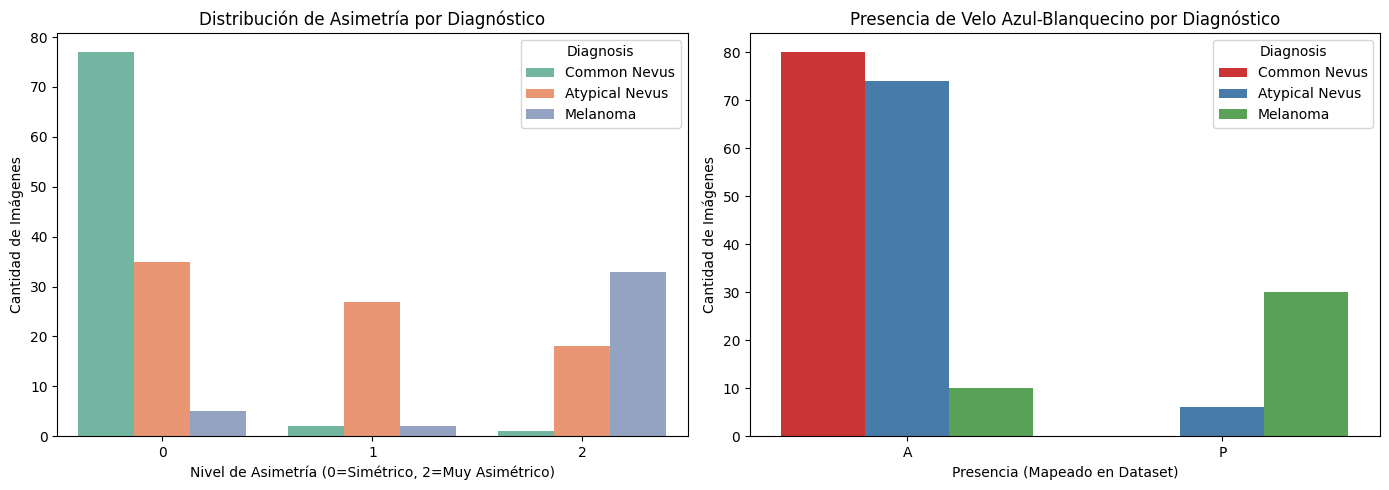


Prueba de Chi-Cuadrado para: Asymmetry
(0/1/2)
 - Estadística Chi2: 134.0262
 - Valor p (p-value): 5.360031e-28
 Resultado: ¡ESTADÍSTICAMENTE SIGNIFICATIVO! La característica define el diagnóstico.

Prueba de Chi-Cuadrado para: Blue-Whitish Veil
(A/P)
 - Estadística Chi2: 111.5854
 - Valor p (p-value): 5.882280e-25
 Resultado: ¡ESTADÍSTICAMENTE SIGNIFICATIVO! La característica define el diagnóstico.


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ==========================================================
# 1. GRÁFICOS DESCRIPTIVOS
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Buscar la columna exacta de asimetría usando coincidencias por si tiene saltos de línea
asym_col = [c for c in df.columns if 'Asymmetry' in c][0]

# Gráfico de Asimetría vs Diagnóstico
sns.countplot(data=df, x=asym_col, hue='Diagnosis', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Asimetría por Diagnóstico')
axes[0].set_xlabel('Nivel de Asimetría (0=Simétrico, 2=Muy Asimétrico)')
axes[0].set_ylabel('Cantidad de Imágenes')

# Gráfico de Velo Azul-Blanquecino vs Diagnóstico
veil_col = [c for c in df.columns if 'Blue-Whitish' in c][0]
sns.countplot(data=df, x=veil_col, hue='Diagnosis', ax=axes[1], palette='Set1')
axes[1].set_title('Presencia de Velo Azul-Blanquecino por Diagnóstico')
axes[1].set_xlabel('Presencia (Mapeado en Dataset)')
axes[1].set_ylabel('Cantidad de Imágenes')

plt.tight_layout()
plt.show()

# ==========================================================
# 2. PRUEBA INFERENCIAL (CHI-CUADRADO)
# ==========================================================
def test_chi2_corregido(dataframe, columna_caracteristica):
    print(f"\nPrueba de Chi-Cuadrado para: {columna_caracteristica}")
    
    # Crear tabla cruzada limpia
    contingency = pd.crosstab(dataframe[columna_caracteristica], dataframe['Diagnosis'])
    
    # Evaluar estadísticos
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f" - Estadística Chi2: {chi2:.4f}")
    print(f" - Valor p (p-value): {p:.6e}")
    
    if p < 0.05:
        print(" Resultado: ¡ESTADÍSTICAMENTE SIGNIFICATIVO! La característica define el diagnóstico.")
    else:
        print(" Resultado: No significativo.")

# Ejecutar las pruebas
test_chi2_corregido(df, asym_col)
test_chi2_corregido(df, veil_col)

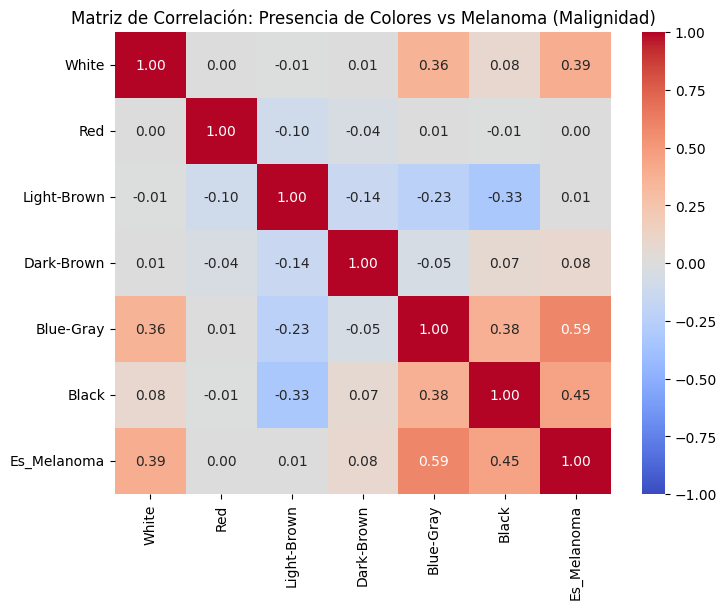

In [13]:
# Lista de colores exacta de las columnas derechas del archivo
color_cols = ['White', 'Red', 'Light-Brown', 'Dark-Brown', 'Blue-Gray', 'Black']

# Asegurar que solo tomamos los colores existentes en el dataframe
color_cols = [c for c in color_cols if c in df.columns]

# Convertir presencia ('X' o texto) a 1, y vacíos a 0
df_colors = df[color_cols].notna() & (df[color_cols] != '')
df_colors = df_colors.astype(int)

# Añadir variable objetivo: 1 si es Melanoma, 0 si es benigno/atípico
df_colors['Es_Melanoma'] = (df['Diagnosis'] == 'Melanoma').astype(int)

# Matriz de Spearman
corr_matrix = df_colors.corr(method='spearman')

# Plot del Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Presencia de Colores vs Melanoma (Malignidad)')
plt.show()

In [18]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# Asegurar variables binarias limpias
df['Is_Melanoma'] = (df['Diagnosis'] == 'Melanoma').astype(int)
asym_col = [c for c in df.columns if 'Asymmetry' in c][0]
veil_col = [c for c in df.columns if 'Blue-Whitish' in c][0]

df['High_Asymmetry'] = (df[asym_col].astype(float) == 2.0).astype(int)
df['Has_Veil'] = (df[veil_col].notna() & (df[veil_col] != '')).astype(int)

def calcular_odds_ratio_seguro(df, predictor, nombre_mostrar):
    # Crear tabla de contingencia 2x2
    # Filas: Predictor (0 o 1) | Columnas: Is_Melanoma (0 o 1)
    tabla = pd.crosstab(df[predictor], df['Is_Melanoma'])
    
    # Si la tabla no es 2x2 por falta de datos, rellenar
    if tabla.shape != (2, 2):
        print(f"Error: La tabla para {nombre_mostrar} no tiene una forma cuadrática 2x2.")
        return
    
    # Extraer cuadrantes: a, b, c, d
    # a: No Expuesto, Sano | b: No Expuesto, Enfermo
    # c: Expuesto, Sano    | d: Expuesto, Enfermo
    a = tabla.iloc[0, 0]
    b = tabla.iloc[0, 1]
    c = tabla.iloc[1, 0]
    d = tabla.iloc[1, 1]
    
    # Corrección de Haldane-Anscombe si hay algún cero para evitar indeterminaciones matemáticas
    if a == 0 or b == 0 or c == 0 or d == 0:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    
    # Cálculo manual del Odds Ratio (Razón de Momios)
    odds_ratio = (num_or := (a * d) / (b * c))
    
    # Error estándar para el Intervalo de Confianza del 95%
    log_se = np.sqrt((1/a) + (1/b) + (1/c) + (1/d))
    ci_lower = np.exp(np.log(odds_ratio) - 1.96 * log_se)
    ci_upper = np.exp(np.log(odds_ratio) + 1.96 * log_se)
    
    # Test Exacto de Fisher (el estándar cuando hay muestras pequeñas o separaciones perfectas)
    _odds, p_value = stats.fisher_exact(tabla)
    
    print(f"{nombre_mostrar}:")
    print(f"  - Tabla de Contingencia:\n{tabla}")
    print(f"  - Odds Ratio (OR): {odds_ratio:.2f}")
    print(f"  - Intervalo de Confianza 95%: [{ci_lower:.2f}, {ci_upper:.2f}]")
    print(f"  - Valor p (Test de Fisher): {p_value:.4e}")
    if p_value < 0.05:
        print("  - Resultado: ¡FACTOR DE RIESGO CLÍNICAMENTE SIGNIFICATIVO!")
    else:
        print("  - Resultado: No estadísticamente significativo.")
    print("-" * 50)

print("="*60)
print("   ANÁLISIS DE RIESGO SEGURO (CORRECCIÓN POR SEPARACIÓN BIOLÓGICA)")
print("="*60)

# Calcular para Velo Azul
calcular_odds_ratio_seguro(df, 'Has_Veil', 'Velo Azul-Blanquecino')

# Calcular para Asimetría Máxima
calcular_odds_ratio_seguro(df, 'High_Asymmetry', 'Asimetría Máxima (Nivel 2)')

print("="*60)

   ANÁLISIS DE RIESGO SEGURO (CORRECCIÓN POR SEPARACIÓN BIOLÓGICA)
Error: La tabla para Velo Azul-Blanquecino no tiene una forma cuadrática 2x2.
Asimetría Máxima (Nivel 2):
  - Tabla de Contingencia:
Is_Melanoma       0   1
High_Asymmetry         
0               141   7
1                19  33
  - Odds Ratio (OR): 34.98
  - Intervalo de Confianza 95%: [13.59, 90.09]
  - Valor p (Test de Fisher): 1.0233e-17
  - Resultado: ¡FACTOR DE RIESGO CLÍNICAMENTE SIGNIFICATIVO!
--------------------------------------------------


In [20]:
# Corrección de sintaxis: usando el accesor .str antes de .strip()
nombre_columna_velo = [c for c in df.columns if 'Blue-Whitish' in c][0]

df['Has_Veil_Fixed'] = df[nombre_columna_velo].str.strip().str.upper() == 'P'
df['Has_Veil_Fixed'] = df['Has_Veil_Fixed'].astype(int)

# Volvemos a lanzar el cálculo seguro
print("="*60)
print("   CÁLCULO CORREGIDO: ODDS RATIO PARA VELO AZUL")
print("="*60)
calcular_odds_ratio_seguro(df, 'Has_Veil_Fixed', 'Velo Azul-Blanquecino (Corregido)')
print("="*60)

   CÁLCULO CORREGIDO: ODDS RATIO PARA VELO AZUL
Velo Azul-Blanquecino (Corregido):
  - Tabla de Contingencia:
Is_Melanoma       0   1
Has_Veil_Fixed         
0               154  10
1                 6  30
  - Odds Ratio (OR): 77.00
  - Intervalo de Confianza 95%: [26.02, 227.90]
  - Valor p (Test de Fisher): 2.8205e-21
  - Resultado: ¡FACTOR DE RIESGO CLÍNICAMENTE SIGNIFICATIVO!
--------------------------------------------------


/tmp/ipykernel_42635/957510968.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X_stats.columns[indices], palette="viridis")


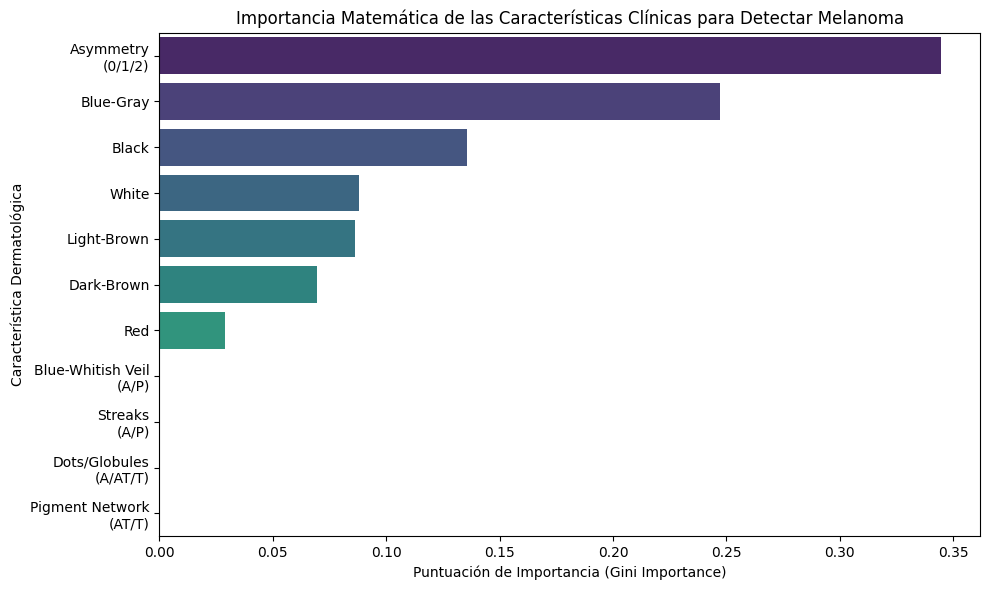

In [16]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Seleccionamos las variables clínicas del PH2
# Red de pigmentos, Asimetría, Estructuras de puntos/glóbulos, estrías, y colores básicos
features_interes = [
    [c for c in df.columns if 'Asymmetry' in c][0],
    [c for c in df.columns if 'Pigment Network' in c][0],
    [c for c in df.columns if 'Dots' in c or 'Globules' in c][0],
    [c for c in df.columns if 'Streaks' in c][0],
    [c for c in df.columns if 'Blue-Whitish' in c][0],
    'White', 'Red', 'Light-Brown', 'Dark-Brown', 'Blue-Gray', 'Black'
]

# Construimos una matriz limpia convirtiendo las marcas de texto 'X' a binarios 1/0
X_stats = pd.DataFrame()
for col in features_interes:
    if col in df.columns:
        # Si la columna es numérica original (como Asimetría que es 0, 1, 2)
        if df[col].dtype in [np.int64, np.float64]:
            X_stats[col] = df[col].fillna(0)
        else:
            # Si contiene 'X' o strings
            X_stats[col] = (df[col].notna() & (df[col] != '')).astype(int)

y_stats = df['Is_Melanoma']

# Entrenamos el clasificador estadístico
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_stats, y_stats)

# Extraemos la importancia
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X_stats.columns[indices], palette="viridis")
plt.title('Importancia Matemática de las Características Clínicas para Detectar Melanoma')
plt.xlabel('Puntuación de Importancia (Gini Importance)')
plt.ylabel('Característica Dermatológica')
plt.tight_layout()
plt.show()

--- MEDIA DE COLORES SIMULTÁNEOS POR DIAGNÓSTICO ---
Diagnosis
Atypical Nevus    1.8625
Common Nevus      1.6125
Melanoma          3.1500
Name: Total_Colors, dtype: float64


/tmp/ipykernel_42635/1635529361.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diagnosis', y='Total_Colors', palette='Pastel1')


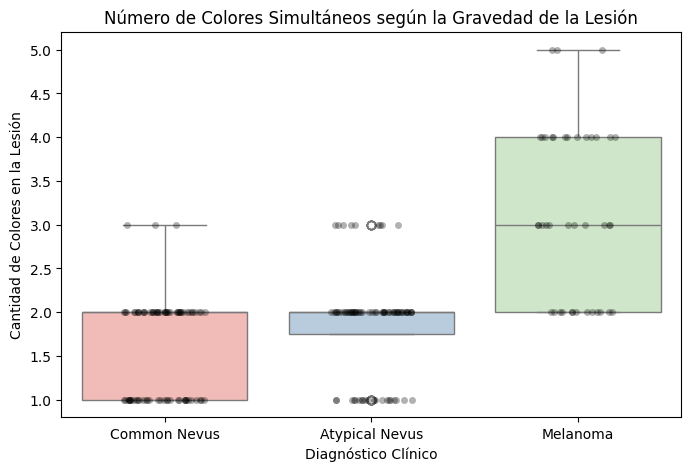


Prueba No Paramétrica de Kruskal-Wallis para el Conteo de Colores:
 - Estadístico H: 68.5204
 - Valor p: 1.321226e-15
 Resultado: ¡ALTAMENTE SIGNIFICATIVO! El número de colores difiere de forma real entre diagnósticos.


In [17]:
from scipy.stats import kruskal

colores_cols = ['White', 'Red', 'Light-Brown', 'Dark-Brown', 'Blue-Gray', 'Black']
colores_cols = [c for c in colores_cols if c in df.columns]

# Contamos cuántos colores diferentes están presentes (tienen marca) en cada fila
df['Total_Colors'] = (df[colores_cols].notna() & (df[colores_cols] != '')).sum(axis=1)

print("--- MEDIA DE COLORES SIMULTÁNEOS POR DIAGNÓSTICO ---")
print(df.groupby('Diagnosis')['Total_Colors'].mean())

# Graficamos el Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Diagnosis', y='Total_Colors', palette='Pastel1')
sns.stripplot(data=df, x='Diagnosis', y='Total_Colors', color='black', alpha=0.3, jitter=0.2)
plt.title('Número de Colores Simultáneos según la Gravedad de la Lesión')
plt.xlabel('Diagnóstico Clínico')
plt.ylabel('Cantidad de Colores en la Lesión')
plt.show()

# Prueba de hipótesis inferencial (Kruskal-Wallis)
grupos = [df[df['Diagnosis'] == diag]['Total_Colors'].values for diag in df['Diagnosis'].unique()]
stat, p_val = kruskal(*grupos)

print("\nPrueba No Paramétrica de Kruskal-Wallis para el Conteo de Colores:")
print(f" - Estadístico H: {stat:.4f}")
print(f" - Valor p: {p_val:.6e}")
if p_val < 0.05:
    print(" Resultado: ¡ALTAMENTE SIGNIFICATIVO! El número de colores difiere de forma real entre diagnósticos.")
else:
    print(" Resultado: No significativo.")

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# 1. Modelos a importar
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ==========================================
# PASO 1: PREPARACIÓN DE CARACTERÍSTICAS
# ==========================================
# Usamos las mismas variables dermatológicas del PH2
features_lista = [
    [c for c in df.columns if 'Asymmetry' in c][0],
    [c for c in df.columns if 'Pigment Network' in c][0],
    [c for c in df.columns if 'Dots' in c or 'Globules' in c][0],
    [c for c in df.columns if 'Streaks' in c][0],
    'Has_Veil_Fixed', 'White', 'Red', 'Light-Brown', 'Dark-Brown', 'Blue-Gray', 'Black'
]

# Construir la matriz X convirtiendo marcas de texto 'X' a binarios 1/0
X_tab = pd.DataFrame()
for col in features_lista:
    if df[col].dtype in [np.int64, np.float64]:
        X_tab[col] = df[col].fillna(0)
    else:
        X_tab[col] = (df[col].notna() & (df[col] != '')).astype(int)

# Target numérico: 0 = Common Nevus, 1 = Atypical Nevus, 2 = Melanoma
# Usamos un mapeo directo para clasificación multiclase
mapeo_clases = {'Common Nevus': 0, 'Atypical Nevus': 1, 'Melanoma': 2}
y_tab = df['Diagnosis'].map(mapeo_clases).values

# Dividir en entrenamiento y validación (mismo tamaño para ser justos)
X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_tab, y_tab, test_size=0.20, random_state=42, stratify=y_tab
)

# Escalar los datos (Crucial para SVM y MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_t)
X_val_scaled = scaler.transform(X_val_t)

# ==========================================
# PASO 2: DEFINICIÓN DE LOS 5 MODELOS
# ==========================================
modelos = {
    "1. Regresión Logística (Lineal)": LogisticRegression(max_iter=1000, random_state=42),
    "2. SVM Lineal (Plano)": SVC(kernel='linear', random_state=42),
    "3. SVM No Lineal (Kernel RBF)": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    "4. Random Forest (No Lineal/Árboles)": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "5. MLP Multicapa (Red Neuronal)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

# ==========================================
# PASO 3: ENTRENAMIENTO Y EVALUACIÓN
# ==========================================
resultados = []

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train_scaled, y_train_t)
    
    # Predecir en validación
    preds = modelo.predict(X_val_scaled)
    
    # Métricas
    acc = accuracy_score(y_val_t, preds)
    # Calculamos el F1-Score específico para la clase Melanoma (etiqueta 2)
    f1_melanoma = f1_score(y_val_t, preds, average=None)[2] 
    
    resultados.append({
        "Modelo": nombre,
        "Accuracy Validación": f"{(acc * 100):.2f}%",
        "F1-Score Melanoma": f"{f1_melanoma:.2f}"
    })

# Convertir a DataFrame elegante para visualizarlo
df_comparativa = pd.DataFrame(resultados)
print("\n" + "="*70)
print("   TABLA COMPARATIVA FINAL DE MODELOS ")
print("="*70)
print(df_comparativa.to_string(index=False))
print("="*70)


   TABLA COMPARATIVA FINAL DE MODELOS 
                              Modelo Accuracy Validación F1-Score Melanoma
     1. Regresión Logística (Lineal)              77.50%              0.93
               2. SVM Lineal (Plano)              80.00%              0.93
       3. SVM No Lineal (Kernel RBF)              82.50%              0.86
4. Random Forest (No Lineal/Árboles)              80.00%              0.93
     5. MLP Multicapa (Red Neuronal)              85.00%              0.93
